# Toy stochastic differential equations: exact solutions and simulations

This notebook develops seven small but important stochastic differential equations (SDEs):

1. Brownian motion
2. Ornstein-Uhlenbeck (OU) process
3. Vasicek / mean-reverting OU process
4. Noisy spring (a linear second-order system)
5. Random-acceleration car / Wiener-velocity model
6. Geometric Brownian motion (the Black-Scholes asset model)
7. Noisy pendulum

The aim is not just to produce plots. For every model we will identify the **drift** and
**diffusion**, decide whether an exact solution is available, explain the main solution
idea, simulate sample paths, and compare Euler-Maruyama with an exact grid-point solution
whenever one exists.

> **Guiding question:** what does it mean to “solve” an SDE?  The answer is usually a
> random process, its distribution, or a rule for drawing its paths - not one deterministic
> curve.

## How this notebook connects to the book

The notation and viewpoint follow Simo Särkkä and Arno Solin,
*Applied Stochastic Differential Equations* (2019), especially Chapters 3-4.
The book writes Brownian motion as $\beta(t)$ in many places; this notebook uses the
equally common symbol $W_t$.

Useful landmarks in the book are:

- Chapter 3, Section 3.1: Brownian motion and physical examples; car (Example 3.4),
  noisy pendulum (Example 3.6), and Black-Scholes (Example 3.8).
- Chapter 3, Sections 3.2-3.3: drift/dispersion, white-noise-driven equations, linear
  SDE solutions and statistics, and the stochastic spring (Example 3.10).
- Equation (3.48): the Euler-Maruyama update.
- Chapter 4, Sections 4.1-4.2: the Itô integral and Itô formula.
- Chapter 4, Section 4.3: exact linear-SDE solution, OU (Example 4.5), and
  Black-Scholes (Example 4.7).
- Chapter 4, Section 4.4: why nonlinear SDEs generally have no universal closed-form
  solution method.
- Exercise 4.4: the mean-reverting OU parameterization known as the Vasicek model.

The car's exact discrete transition covariance is also shown later in the book as the
Wiener-velocity model (Example 6.3). We use that result after deriving it from the same
linear-SDE formula introduced in Chapters 3-4.

## 0. The common language of all the examples

A scalar Itô SDE has the form

$$
dX_t = a(X_t,t)\,dt + b(X_t,t)\,dW_t.
$$

- $a$ is the **drift**. It describes the systematic motion we would see if the random
  forcing were removed.
- $b$ is the **diffusion** (called the dispersion in parts of the book). It controls how
  strongly Brownian noise enters the state.
- $W_t$ is standard Brownian motion. Over a short interval of length $\Delta t$,

  $$\Delta W_k = W_{t_{k+1}}-W_{t_k} \sim \mathcal N(0,\Delta t).$$

The crucial scaling is therefore $\Delta W_k=O(\sqrt{\Delta t})$, not
$O(\Delta t)$. Informally writing $w(t)=dW_t/dt$ is useful intuition, but white noise is
not an ordinary function; the Itô integral gives the equation its precise meaning.

For a vector state $X_t\in\mathbb R^d$ we write

$$dX_t=f(X_t,t)\,dt+L(X_t,t)\,dW_t.$$

In [1]:
from collections.abc import Callable

import matplotlib.pyplot as plt
import numpy as np
from numpy.random import Generator
from scipy.linalg import expm
from scipy.stats import norm

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (11, 4.5),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "figure.dpi": 120,
    }
)

SEED = 2026
BLUE = "#2563eb"
ORANGE = "#ea580c"
GREEN = "#059669"
PURPLE = "#7c3aed"
GRAY = "#64748b"

print(f"NumPy {np.__version__}; fixed random seed = {SEED}")

NumPy 2.2.6; fixed random seed = 2026


### Euler-Maruyama: Euler's method with Brownian increments

Integrating the SDE over one short interval and freezing the coefficients at the left
endpoint gives

$$
X_{k+1}^{\mathrm{EM}}
=X_k^{\mathrm{EM}}
+a(X_k^{\mathrm{EM}},t_k)\Delta t
+b(X_k^{\mathrm{EM}},t_k)\Delta W_k,
\qquad \Delta W_k\sim\mathcal N(0,\Delta t).
$$

This is Euler-Maruyama (EM), the stochastic analogue of forward Euler. The book notes
after Equation (3.48) that it converges to the true path as $\Delta t\to0$, but its
general strong (pathwise) convergence order is only $1/2$.

Two notions of accuracy are useful:

- **Strong/pathwise accuracy:** does the numerical path follow the exact path generated
  by the same Brownian motion?
- **Weak/distributional accuracy:** are expectations, variances, quantiles, and other
  distributional summaries correct?

We examine both. When comparing paths, the exact and EM solutions below share the same
Brownian increments. For additive-noise linear systems, a small independent “Brownian
bridge” term supplies the within-step randomness needed by the exact transition.

In [2]:
ScalarFunction = Callable[[np.ndarray, float], np.ndarray]


def make_time_grid(final_time: float, step: float) -> np.ndarray:
    """Create a uniform grid and reject incompatible final-time/step pairs."""
    if final_time <= 0 or step <= 0:
        raise ValueError("final_time and step must be positive")
    n_steps = int(round(final_time / step))
    if not np.isclose(n_steps * step, final_time):
        raise ValueError("final_time must be an integer multiple of step")
    return np.linspace(0.0, final_time, n_steps + 1)


def brownian_increments(
    rng: Generator, n_paths: int, n_steps: int, step: float
) -> np.ndarray:
    """Draw independent standard-Brownian increments."""
    if n_paths < 1 or n_steps < 1:
        raise ValueError("n_paths and n_steps must be positive")
    return np.sqrt(step) * rng.standard_normal((n_paths, n_steps))


def euler_maruyama_scalar(
    drift: ScalarFunction,
    diffusion: ScalarFunction,
    initial_value: float,
    times: np.ndarray,
    increments: np.ndarray,
) -> np.ndarray:
    """Simulate scalar Itô SDE paths with Euler-Maruyama."""
    n_paths, n_steps = increments.shape
    if times.size != n_steps + 1:
        raise ValueError("times and increments have incompatible shapes")
    paths = np.empty((n_paths, n_steps + 1), dtype=float)
    paths[:, 0] = initial_value
    for k in range(n_steps):
        step = times[k + 1] - times[k]
        current = paths[:, k]
        paths[:, k + 1] = (
            current
            + drift(current, times[k]) * step
            + diffusion(current, times[k]) * increments[:, k]
        )
    return paths


def psd_square_root(covariance: np.ndarray) -> np.ndarray:
    """Return a stable symmetric square root of a PSD covariance matrix."""
    symmetric = 0.5 * (covariance + covariance.T)
    eigenvalues, eigenvectors = np.linalg.eigh(symmetric)
    scale = max(1.0, float(np.max(np.abs(eigenvalues))))
    if np.min(eigenvalues) < -1e-10 * scale:
        raise ValueError("covariance is not positive semidefinite")
    clipped = np.clip(eigenvalues, 0.0, None)
    return (eigenvectors * np.sqrt(clipped)) @ eigenvectors.T


def linear_sde_step_matrices(
    drift_matrix: np.ndarray, diffusion_vector: np.ndarray, step: float
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Exact one-step mean, covariance, and Brownian cross-covariance.

    The model is dX = F X dt + L dW for a scalar standard Brownian motion.
    Q_step is the covariance of the exact stochastic convolution over one step.
    C_step = Cov(exact innovation, Delta W).
    """
    drift_matrix = np.asarray(drift_matrix, dtype=float)
    diffusion_vector = np.asarray(diffusion_vector, dtype=float).reshape(-1, 1)
    dimension = drift_matrix.shape[0]
    if drift_matrix.shape != (dimension, dimension):
        raise ValueError("drift_matrix must be square")
    if diffusion_vector.shape != (dimension, 1):
        raise ValueError("diffusion_vector has the wrong dimension")

    noise_covariance = diffusion_vector @ diffusion_vector.T
    van_loan = np.block(
        [
            [drift_matrix, noise_covariance],
            [np.zeros_like(drift_matrix), -drift_matrix.T],
        ]
    )
    van_loan_exp = expm(van_loan * step)
    transition = van_loan_exp[:dimension, :dimension]
    step_covariance = van_loan_exp[:dimension, dimension:] @ transition.T
    step_covariance = 0.5 * (step_covariance + step_covariance.T)

    augmented = np.block(
        [
            [drift_matrix, diffusion_vector],
            [np.zeros((1, dimension)), np.zeros((1, 1))],
        ]
    )
    brownian_cross_covariance = expm(augmented * step)[:dimension, dimension:]
    return transition, step_covariance, brownian_cross_covariance


def coupled_linear_exact_and_em(
    drift_matrix: np.ndarray,
    diffusion_vector: np.ndarray,
    initial_state: np.ndarray,
    times: np.ndarray,
    rng: Generator,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Simulate exact and EM paths coupled to the same scalar Brownian motion."""
    step = times[1] - times[0]
    transition, step_covariance, cross_covariance = linear_sde_step_matrices(
        drift_matrix, diffusion_vector, step
    )
    dimension = initial_state.size
    n_steps = times.size - 1
    exact = np.empty((n_steps + 1, dimension))
    em = np.empty_like(exact)
    exact[0] = initial_state
    em[0] = initial_state

    increments = np.sqrt(step) * rng.standard_normal(n_steps)
    residual_covariance = (
        step_covariance - cross_covariance @ cross_covariance.T / step
    )
    residual_root = psd_square_root(residual_covariance)
    bridge_normals = rng.standard_normal((n_steps, dimension))
    diffusion_vector = np.asarray(diffusion_vector, dtype=float).reshape(-1)

    for k in range(n_steps):
        exact_innovation = (
            cross_covariance[:, 0] * increments[k] / step
            + residual_root @ bridge_normals[k]
        )
        exact[k + 1] = transition @ exact[k] + exact_innovation
        em[k + 1] = (
            em[k]
            + drift_matrix @ em[k] * step
            + diffusion_vector * increments[k]
        )
    return exact, em, increments


def exact_linear_ensemble(
    drift_matrix: np.ndarray,
    diffusion_vector: np.ndarray,
    initial_state: np.ndarray,
    times: np.ndarray,
    n_paths: int,
    rng: Generator,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Draw exact grid-point paths and propagate their theoretical moments."""
    step = times[1] - times[0]
    transition, step_covariance, _ = linear_sde_step_matrices(
        drift_matrix, diffusion_vector, step
    )
    dimension = initial_state.size
    paths = np.empty((n_paths, times.size, dimension))
    means = np.empty((times.size, dimension))
    covariances = np.empty((times.size, dimension, dimension))
    paths[:, 0, :] = initial_state
    means[0] = initial_state
    covariances[0] = 0.0
    noise_root = psd_square_root(step_covariance)

    for k in range(times.size - 1):
        innovations = rng.standard_normal((n_paths, dimension)) @ noise_root.T
        paths[:, k + 1, :] = paths[:, k, :] @ transition.T + innovations
        means[k + 1] = transition @ means[k]
        covariances[k + 1] = (
            transition @ covariances[k] @ transition.T + step_covariance
        )
    return paths, means, covariances


def add_gaussian_band(
    axis: plt.Axes,
    times: np.ndarray,
    mean: np.ndarray,
    standard_deviation: np.ndarray,
    color: str = BLUE,
    label: str = "theory: mean +/- 1.96 sd",
) -> None:
    """Draw a Gaussian mean and pointwise 95% band."""
    axis.plot(times, mean, color=color, linewidth=2.2, label="theoretical mean")
    axis.fill_between(
        times,
        mean - 1.96 * standard_deviation,
        mean + 1.96 * standard_deviation,
        color=color,
        alpha=0.16,
        label=label,
    )

## 1. Brownian motion: accumulating independent random increments

The simplest SDE is

$$dX_t=\sigma\,dW_t,\qquad X_0=x_0.$$

**Drift:** $a=0$. There is no preferred direction.

**Diffusion:** $b=\sigma$. Larger $\sigma$ means larger random steps.

Integrating both sides immediately gives the exact solution

$$X_t=x_0+\sigma W_t.$$

Since $W_t\sim\mathcal N(0,t)$,

$$\mathbb E[X_t]=x_0,\qquad \operatorname{Var}(X_t)=\sigma^2t.$$

This is the continuous-time random walk introduced around Equation (3.9) and defined
rigorously in Chapter 4. On a grid, Euler-Maruyama is not merely approximate here:

$$X_{k+1}=X_k+\sigma\Delta W_k$$

is exactly the Brownian solution at the grid points.

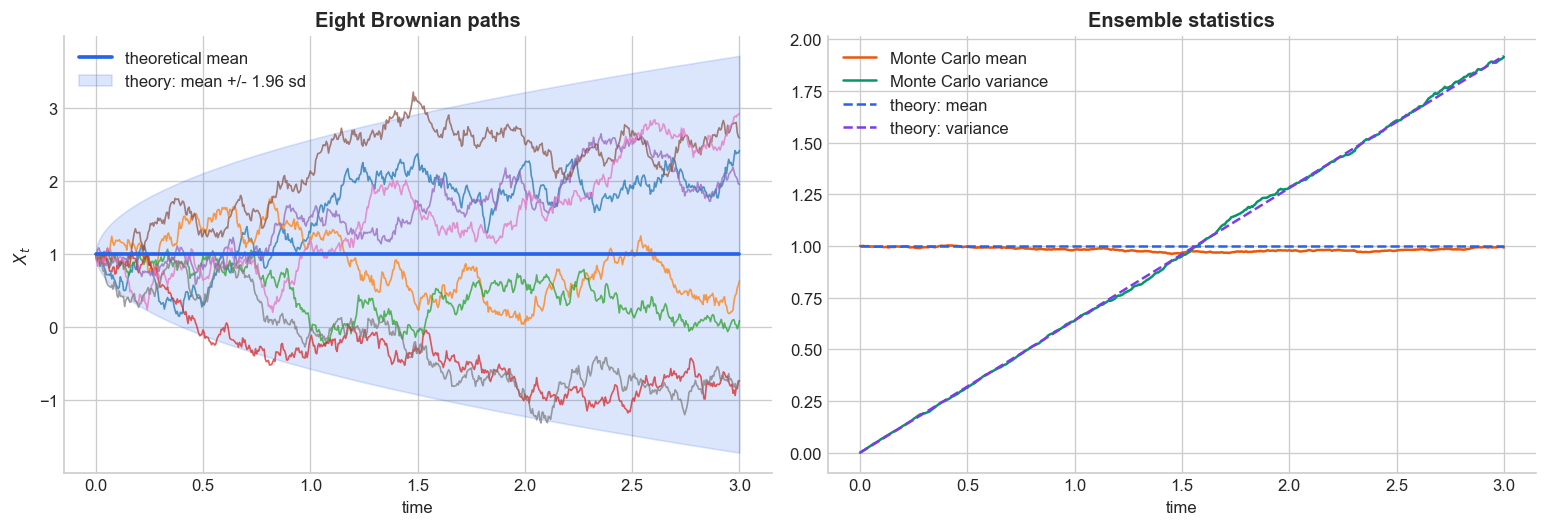

Maximum exact-vs-EM grid error: 1.243e-14


In [3]:
rng = np.random.default_rng(SEED + 1)
brownian_times = make_time_grid(final_time=3.0, step=0.005)
brownian_step = brownian_times[1] - brownian_times[0]
brownian_dW = brownian_increments(
    rng, n_paths=2500, n_steps=brownian_times.size - 1, step=brownian_step
)

x0_bm, sigma_bm = 1.0, 0.8
brownian_W = np.column_stack(
    [np.zeros(brownian_dW.shape[0]), np.cumsum(brownian_dW, axis=1)]
)
brownian_exact = x0_bm + sigma_bm * brownian_W
brownian_em = euler_maruyama_scalar(
    drift=lambda x, t: np.zeros_like(x),
    diffusion=lambda x, t: sigma_bm * np.ones_like(x),
    initial_value=x0_bm,
    times=brownian_times,
    increments=brownian_dW,
)

brownian_mean = np.full_like(brownian_times, x0_bm)
brownian_sd = sigma_bm * np.sqrt(brownian_times)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(
    brownian_times,
    brownian_exact[:8].T,
    linewidth=1.0,
    alpha=0.75,
)
add_gaussian_band(axes[0], brownian_times, brownian_mean, brownian_sd)
axes[0].set(title="Eight Brownian paths", xlabel="time", ylabel="$X_t$")
axes[0].legend(loc="upper left")

axes[1].plot(
    brownian_times,
    brownian_exact.mean(axis=0),
    color=ORANGE,
    label="Monte Carlo mean",
)
axes[1].plot(
    brownian_times,
    brownian_exact.var(axis=0),
    color=GREEN,
    label="Monte Carlo variance",
)
axes[1].plot(
    brownian_times,
    brownian_mean,
    "--",
    color=BLUE,
    label="theory: mean",
)
axes[1].plot(
    brownian_times,
    sigma_bm**2 * brownian_times,
    "--",
    color=PURPLE,
    label="theory: variance",
)
axes[1].set(title="Ensemble statistics", xlabel="time")
axes[1].legend()
plt.tight_layout()
plt.show()

brownian_max_error = np.max(np.abs(brownian_exact - brownian_em))
print(f"Maximum exact-vs-EM grid error: {brownian_max_error:.3e}")

**What to notice.** Individual paths wander, but the ensemble mean stays at $x_0$.
The uncertainty grows linearly in variance and like $\sqrt{t}$ in standard deviation.
The printed exact-versus-EM error is numerical roundoff: constant-diffusion Brownian
motion is one of the rare cases where EM is exact at every grid point.

## 2. Ornstein-Uhlenbeck process: random motion pulled toward zero

The OU SDE is

$$dX_t=-\lambda X_t\,dt+\sigma\,dW_t,\qquad \lambda>0.$$

**Drift:** $-\lambda X_t$. A positive state is pushed down and a negative state is pushed
up, so zero is a stable equilibrium. The parameter $\lambda$ sets the return speed.

**Diffusion:** constant $\sigma$. Noise keeps kicking the process away from equilibrium.

This is a scalar linear SDE. Multiply by the integrating factor $e^{\lambda t}$, apply
the Itô product rule, and integrate. The exact solution (Example 4.5) is

$$
X_t=e^{-\lambda t}X_0
+\sigma\int_0^t e^{-\lambda(t-s)}\,dW_s.
$$

The Itô integral is Gaussian with mean zero. For deterministic $X_0=x_0$,

$$
\mathbb E[X_t]=x_0e^{-\lambda t},\qquad
\operatorname{Var}(X_t)=\frac{\sigma^2}{2\lambda}
\left(1-e^{-2\lambda t}\right).
$$

Unlike Brownian motion, its variance approaches the finite stationary value
$\sigma^2/(2\lambda)$. The exact one-step transition is

$$
X_{k+1}=e^{-\lambda h}X_k+\eta_k,qquad
\eta_k\sim\mathcal N\!\left(0,
\frac{\sigma^2}{2\lambda}(1-e^{-2\lambda h})\right).
$$

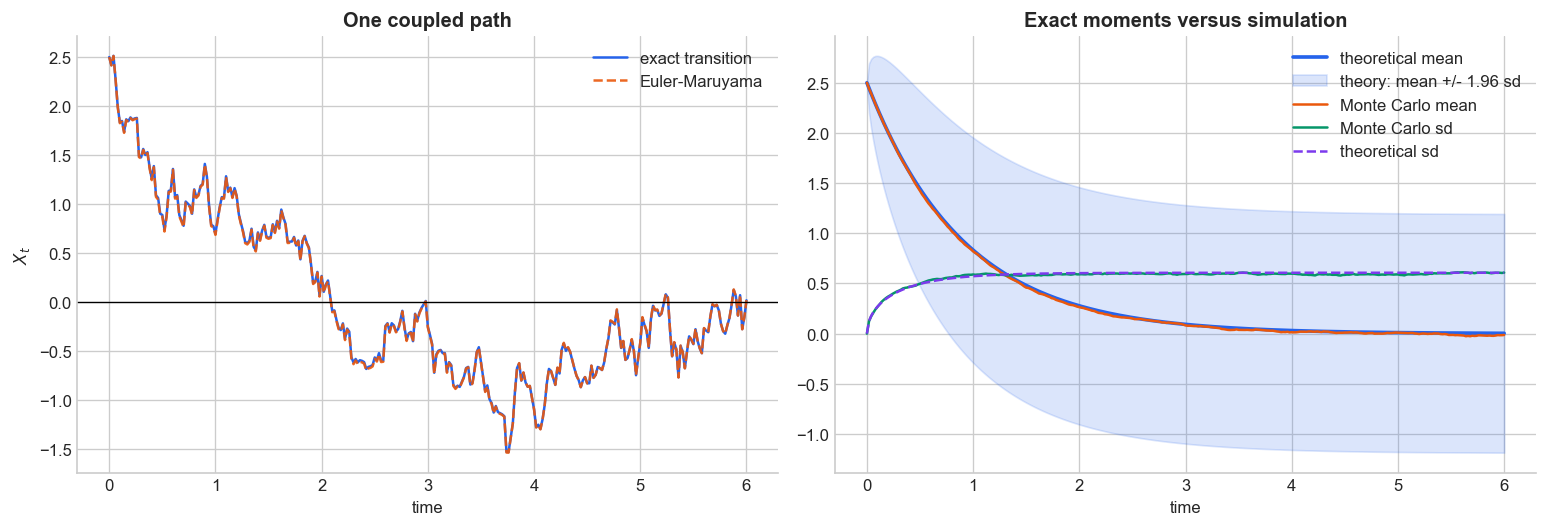

Pathwise exact-vs-EM RMSE at h=0.02: 0.0083
Stationary standard deviation: 0.6068


In [4]:
rng = np.random.default_rng(SEED + 2)
ou_times = make_time_grid(final_time=6.0, step=0.02)
ou_step = ou_times[1] - ou_times[0]
lambda_ou, sigma_ou, x0_ou = 1.1, 0.9, 2.5

ou_F = np.array([[-lambda_ou]])
ou_L = np.array([sigma_ou])
ou_exact_path, ou_em_path, _ = coupled_linear_exact_and_em(
    ou_F, ou_L, np.array([x0_ou]), ou_times, rng
)
ou_paths, ou_recursive_mean, ou_recursive_cov = exact_linear_ensemble(
    ou_F,
    ou_L,
    np.array([x0_ou]),
    ou_times,
    n_paths=2200,
    rng=rng,
)

ou_mean = x0_ou * np.exp(-lambda_ou * ou_times)
ou_variance = sigma_ou**2 / (2 * lambda_ou) * (
    1 - np.exp(-2 * lambda_ou * ou_times)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(ou_times, ou_exact_path[:, 0], color=BLUE, label="exact transition")
axes[0].plot(
    ou_times,
    ou_em_path[:, 0],
    "--",
    color=ORANGE,
    alpha=0.9,
    label="Euler-Maruyama",
)
axes[0].axhline(0.0, color="black", linewidth=0.8)
axes[0].set(title="One coupled path", xlabel="time", ylabel="$X_t$")
axes[0].legend()

add_gaussian_band(axes[1], ou_times, ou_mean, np.sqrt(ou_variance))
axes[1].plot(
    ou_times,
    ou_paths[:, :, 0].mean(axis=0),
    color=ORANGE,
    linewidth=1.5,
    label="Monte Carlo mean",
)
axes[1].plot(
    ou_times,
    ou_paths[:, :, 0].std(axis=0),
    color=GREEN,
    linewidth=1.5,
    label="Monte Carlo sd",
)
axes[1].plot(
    ou_times,
    np.sqrt(ou_variance),
    "--",
    color=PURPLE,
    label="theoretical sd",
)
axes[1].set(title="Exact moments versus simulation", xlabel="time")
axes[1].legend()
plt.tight_layout()
plt.show()

ou_rmse = np.sqrt(np.mean((ou_exact_path[:, 0] - ou_em_path[:, 0]) ** 2))
print(f"Pathwise exact-vs-EM RMSE at h={ou_step:g}: {ou_rmse:.4f}")
print(
    "Stationary standard deviation:",
    f"{sigma_ou / np.sqrt(2 * lambda_ou):.4f}",
)
assert np.allclose(ou_recursive_mean[:, 0], ou_mean)
assert np.allclose(ou_recursive_cov[:, 0, 0], ou_variance)

**What to notice.** The initial condition is gradually forgotten: the exact mean decays
to zero, while the random forcing leaves a nonzero long-run spread. EM follows the same
Brownian driver, but its straight one-step approximation produces a visible (and
measurable) pathwise error.

## 3. Vasicek / mean-reverting OU: pull toward a nonzero level

The finance-style parameterization in Exercise 4.4 is

$$dX_t=\theta(\mu-X_t)\,dt+\sigma\,dW_t,
\qquad \theta>0.$$

**Drift:** $\theta(\mu-X_t)$. The sign always points toward $\mu$.

**Diffusion:** constant $\sigma$.

Set $Y_t=X_t-\mu$. Then $dY_t=-\theta Y_t\,dt+\sigma\,dW_t$, which is the zero-mean
OU equation already solved. Transforming back gives

$$
X_t=\mu+(X_0-\mu)e^{-\theta t}
+\sigma\int_0^t e^{-\theta(t-s)}\,dW_s.
$$

Therefore

$$
\mathbb E[X_t]=\mu+(x_0-\mu)e^{-\theta t},\qquad
\operatorname{Var}(X_t)=\frac{\sigma^2}{2\theta}
(1-e^{-2\theta t}).
$$

Its stationary distribution is $\mathcal N(\mu,\sigma^2/(2\theta))$. In interest-rate
applications the Gaussian model can generate negative values; that is a modeling feature
to consider, not a numerical bug.

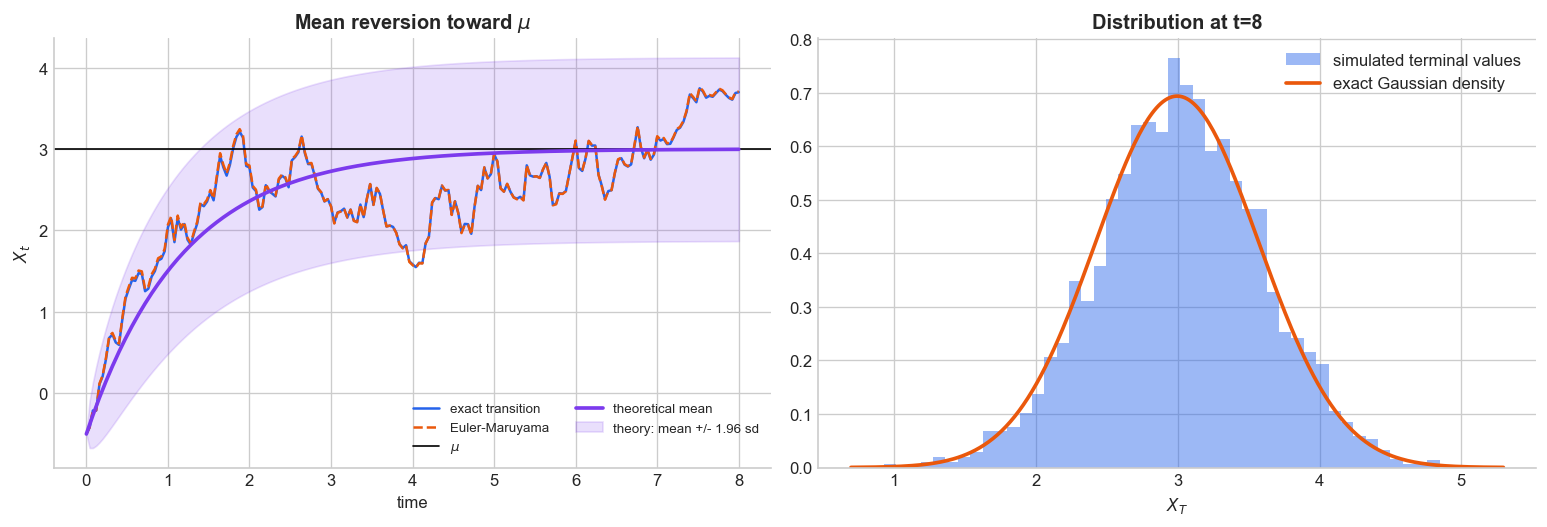

Pathwise exact-vs-EM RMSE at h=0.04: 0.0146
Terminal empirical/theoretical mean: 3.0158 / 2.9961


In [5]:
rng = np.random.default_rng(SEED + 3)
vasicek_times = make_time_grid(final_time=8.0, step=0.04)
vasicek_step = vasicek_times[1] - vasicek_times[0]
theta_v, mu_v, sigma_v, x0_v = 0.85, 3.0, 0.75, -0.5

vasicek_a = np.exp(-theta_v * vasicek_step)
vasicek_q = sigma_v**2 / (2 * theta_v) * (1 - vasicek_a**2)
vasicek_c = sigma_v * (1 - vasicek_a) / theta_v
vasicek_residual_variance = max(
    0.0, vasicek_q - vasicek_c**2 / vasicek_step
)

vasicek_dW = np.sqrt(vasicek_step) * rng.standard_normal(vasicek_times.size - 1)
vasicek_bridge = rng.standard_normal(vasicek_times.size - 1)
vasicek_exact_path = np.empty(vasicek_times.size)
vasicek_em_path = np.empty_like(vasicek_exact_path)
vasicek_exact_path[0] = vasicek_em_path[0] = x0_v
for k in range(vasicek_times.size - 1):
    exact_innovation = (
        vasicek_c / vasicek_step * vasicek_dW[k]
        + np.sqrt(vasicek_residual_variance) * vasicek_bridge[k]
    )
    vasicek_exact_path[k + 1] = (
        mu_v + vasicek_a * (vasicek_exact_path[k] - mu_v) + exact_innovation
    )
    vasicek_em_path[k + 1] = (
        vasicek_em_path[k]
        + theta_v * (mu_v - vasicek_em_path[k]) * vasicek_step
        + sigma_v * vasicek_dW[k]
    )

n_vasicek_paths = 3500
vasicek_ensemble = np.empty((n_vasicek_paths, vasicek_times.size))
vasicek_ensemble[:, 0] = x0_v
for k in range(vasicek_times.size - 1):
    vasicek_ensemble[:, k + 1] = (
        mu_v
        + vasicek_a * (vasicek_ensemble[:, k] - mu_v)
        + np.sqrt(vasicek_q) * rng.standard_normal(n_vasicek_paths)
    )

vasicek_mean = mu_v + (x0_v - mu_v) * np.exp(-theta_v * vasicek_times)
vasicek_variance = sigma_v**2 / (2 * theta_v) * (
    1 - np.exp(-2 * theta_v * vasicek_times)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(vasicek_times, vasicek_exact_path, color=BLUE, label="exact transition")
axes[0].plot(
    vasicek_times,
    vasicek_em_path,
    "--",
    color=ORANGE,
    label="Euler-Maruyama",
)
axes[0].axhline(mu_v, color="black", linewidth=1, label="$\mu$")
add_gaussian_band(
    axes[0], vasicek_times, vasicek_mean, np.sqrt(vasicek_variance), color=PURPLE
)
axes[0].set(title="Mean reversion toward $\mu$", xlabel="time", ylabel="$X_t$")
axes[0].legend(ncol=2, fontsize=8)

terminal_grid = np.linspace(
    vasicek_mean[-1] - 4 * np.sqrt(vasicek_variance[-1]),
    vasicek_mean[-1] + 4 * np.sqrt(vasicek_variance[-1]),
    300,
)
axes[1].hist(
    vasicek_ensemble[:, -1],
    bins=45,
    density=True,
    alpha=0.45,
    color=BLUE,
    label="simulated terminal values",
)
axes[1].plot(
    terminal_grid,
    norm.pdf(
        terminal_grid,
        loc=vasicek_mean[-1],
        scale=np.sqrt(vasicek_variance[-1]),
    ),
    color=ORANGE,
    linewidth=2.2,
    label="exact Gaussian density",
)
axes[1].set(title=f"Distribution at t={vasicek_times[-1]:g}", xlabel="$X_T$")
axes[1].legend()
plt.tight_layout()
plt.show()

vasicek_rmse = np.sqrt(np.mean((vasicek_exact_path - vasicek_em_path) ** 2))
print(f"Pathwise exact-vs-EM RMSE at h={vasicek_step:g}: {vasicek_rmse:.4f}")
print(
    "Terminal empirical/theoretical mean:",
    f"{vasicek_ensemble[:, -1].mean():.4f} / {vasicek_mean[-1]:.4f}",
)

**What to notice.** Vasicek is not a new mathematical species; it is OU shifted by
$\mu$. That simple change of variables is the entire derivation. The terminal histogram
matches a Gaussian because the equation is linear with additive Gaussian noise.

## A reusable exact formula for linear additive-noise systems

The next two models use a vector state. For

$$dX_t=F X_t\,dt+L\,dW_t,$$

Chapter 4, Section 4.3 gives

$$
X_t=e^{F(t-t_0)}X_{t_0}
+\int_{t_0}^{t}e^{F(t-s)}L\,dW_s.
$$

The matrix exponential propagates the deterministic state; the stochastic integral
accumulates every past random kick after the system has filtered it. Over one step $h$,

$$
X_{k+1}=A X_k+\varepsilon_k,\qquad A=e^{Fh},
$$

where $\varepsilon_k$ is zero-mean Gaussian with

$$
Q_h=\int_0^h e^{F\tau}LL^\top e^{F^\top\tau}\,d\tau.
$$

The helper above computes $A$ and $Q_h$ with a block matrix exponential. That produces
exact draws **at the chosen grid points**, even though the integral is not usually written
as an elementary function of one Gaussian number.

## 4. Noisy spring: a linear second-order SDE

Start from the damped spring with a random force,

$$\ddot x_t+\gamma\dot x_t+\nu^2x_t=\sigma\,\frac{dW_t}{dt}.$$

Introduce position $X_{1,t}=x_t$ and velocity $X_{2,t}=\dot x_t$. Then

$$
d\begin{pmatrix}X_{1,t}\\X_{2,t}\end{pmatrix}
=
\underbrace{\begin{pmatrix}0&1\\-\nu^2&-\gamma\end{pmatrix}}_F
\begin{pmatrix}X_{1,t}\\X_{2,t}\end{pmatrix}dt
+
\underbrace{\begin{pmatrix}0\\\sigma\end{pmatrix}}_L dW_t.
$$

**Drift:** the familiar deterministic spring dynamics. Position changes according to
velocity; acceleration contains the restoring force $-\nu^2x$ and damping $-\gamma v$.

**Diffusion:** noise enters acceleration only. Position becomes random indirectly through
velocity.

This is the stochastic spring of Example 3.10 (we absorb the book's white-noise spectral
density into $\sigma$). Because the state equation is linear, the matrix formula above is
exact. Its mean and covariance satisfy

$$\dot m=Fm,\qquad \dot P=FP+PF^\top+LL^\top.$$

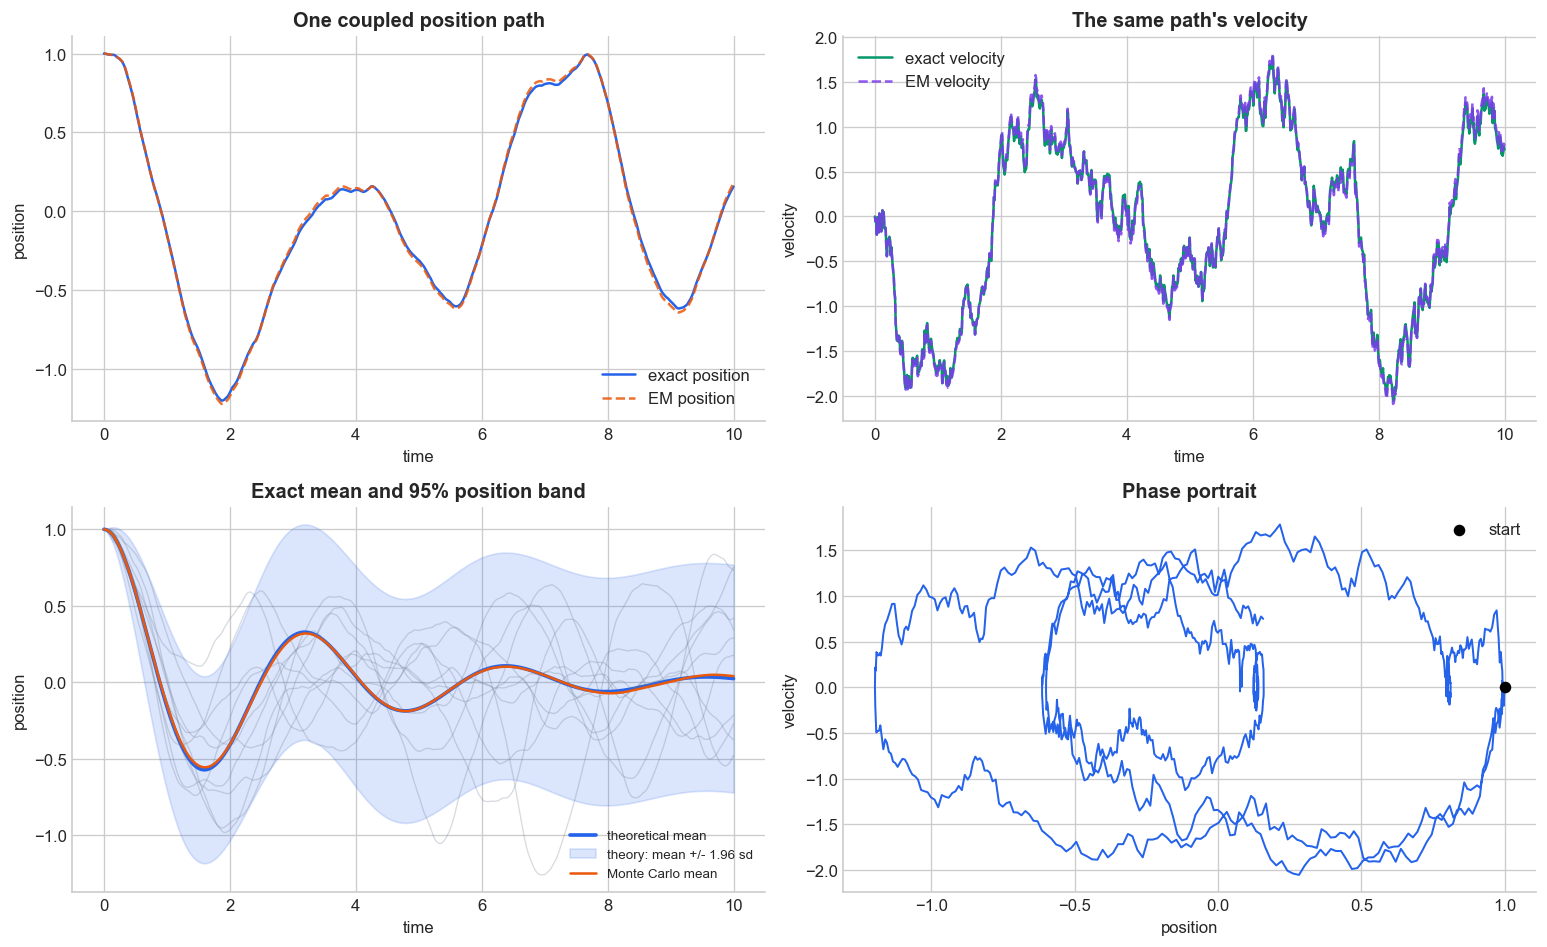

Exact-vs-EM RMSE at h=0.01: position=0.0159, velocity=0.0327
Smallest exact covariance eigenvalue: 0.000e+00


In [6]:
rng = np.random.default_rng(SEED + 4)
spring_times = make_time_grid(final_time=10.0, step=0.01)
spring_step = spring_times[1] - spring_times[0]
gamma_s, nu_s, sigma_s = 0.7, 2.0, 0.9
spring_F = np.array([[0.0, 1.0], [-nu_s**2, -gamma_s]])
spring_L = np.array([0.0, sigma_s])
spring_initial = np.array([1.0, 0.0])

spring_exact_path, spring_em_path, _ = coupled_linear_exact_and_em(
    spring_F, spring_L, spring_initial, spring_times, rng
)
spring_paths, spring_mean, spring_covariance = exact_linear_ensemble(
    spring_F,
    spring_L,
    spring_initial,
    spring_times,
    n_paths=1400,
    rng=rng,
)
spring_position_sd = np.sqrt(spring_covariance[:, 0, 0])

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].plot(
    spring_times, spring_exact_path[:, 0], color=BLUE, label="exact position"
)
axes[0, 0].plot(
    spring_times,
    spring_em_path[:, 0],
    "--",
    color=ORANGE,
    alpha=0.85,
    label="EM position",
)
axes[0, 0].set(title="One coupled position path", xlabel="time", ylabel="position")
axes[0, 0].legend()

axes[0, 1].plot(
    spring_times, spring_exact_path[:, 1], color=GREEN, label="exact velocity"
)
axes[0, 1].plot(
    spring_times,
    spring_em_path[:, 1],
    "--",
    color=PURPLE,
    alpha=0.85,
    label="EM velocity",
)
axes[0, 1].set(title="The same path's velocity", xlabel="time", ylabel="velocity")
axes[0, 1].legend()

add_gaussian_band(
    axes[1, 0], spring_times, spring_mean[:, 0], spring_position_sd
)
for path in spring_paths[:10, :, 0]:
    axes[1, 0].plot(spring_times, path, color=GRAY, alpha=0.25, linewidth=0.8)
axes[1, 0].plot(
    spring_times,
    spring_paths[:, :, 0].mean(axis=0),
    color=ORANGE,
    label="Monte Carlo mean",
)
axes[1, 0].set(
    title="Exact mean and 95% position band", xlabel="time", ylabel="position"
)
axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(
    spring_exact_path[:, 0],
    spring_exact_path[:, 1],
    color=BLUE,
    linewidth=1.2,
)
axes[1, 1].scatter(
    spring_exact_path[0, 0],
    spring_exact_path[0, 1],
    color="black",
    s=35,
    label="start",
    zorder=3,
)
axes[1, 1].set(
    title="Phase portrait", xlabel="position", ylabel="velocity"
)
axes[1, 1].legend()
plt.tight_layout()
plt.show()

spring_rmse = np.sqrt(np.mean((spring_exact_path - spring_em_path) ** 2, axis=0))
print(
    f"Exact-vs-EM RMSE at h={spring_step:g}: "
    f"position={spring_rmse[0]:.4f}, velocity={spring_rmse[1]:.4f}"
)
print(
    "Smallest exact covariance eigenvalue:",
    f"{min(np.linalg.eigvalsh(cov).min() for cov in spring_covariance):.3e}",
)

**What to notice.** Randomness enters only the velocity equation, yet position becomes
uncertain because velocity is integrated. Damping removes memory of the initial
displacement, while continuing noise maintains random oscillations. The mean behaves like
the deterministic zero-force spring; the covariance records the spread around that mean.

## 5. Random-acceleration car: noise enters acceleration

In one spatial dimension,

$$dX_t=V_t\,dt,\qquad dV_t=\sigma\,dW_t.$$

Equivalently,

$$
d\begin{pmatrix}X_t\\V_t\end{pmatrix}
=
\begin{pmatrix}0&1\\0&0\end{pmatrix}
\begin{pmatrix}X_t\\V_t\end{pmatrix}dt
+\begin{pmatrix}0\\\sigma\end{pmatrix}dW_t.
$$

**Drift:** position changes at the current velocity; velocity has no deterministic trend.

**Diffusion:** random acceleration changes velocity directly.

Integrating gives the exact continuous-time representation

$$
V_t=v_0+\sigma W_t,
\qquad
X_t=x_0+v_0t+\sigma\int_0^t(t-s)\,dW_s.
$$

Hence the state is jointly Gaussian, with

$$
\mathbb E\!\begin{bmatrix}X_t\\V_t\end{bmatrix}
=\begin{bmatrix}x_0+v_0t\\v_0\end{bmatrix},\qquad
\operatorname{Cov}\!\begin{bmatrix}X_t\\V_t\end{bmatrix}
=\sigma^2\begin{bmatrix}t^3/3&t^2/2\\t^2/2&t\end{bmatrix}.
$$

The $t^3$ position variance is the signature of integrating Brownian velocity. The book's
two-dimensional car (Example 3.4) uses one independent copy of this model per spatial
direction.

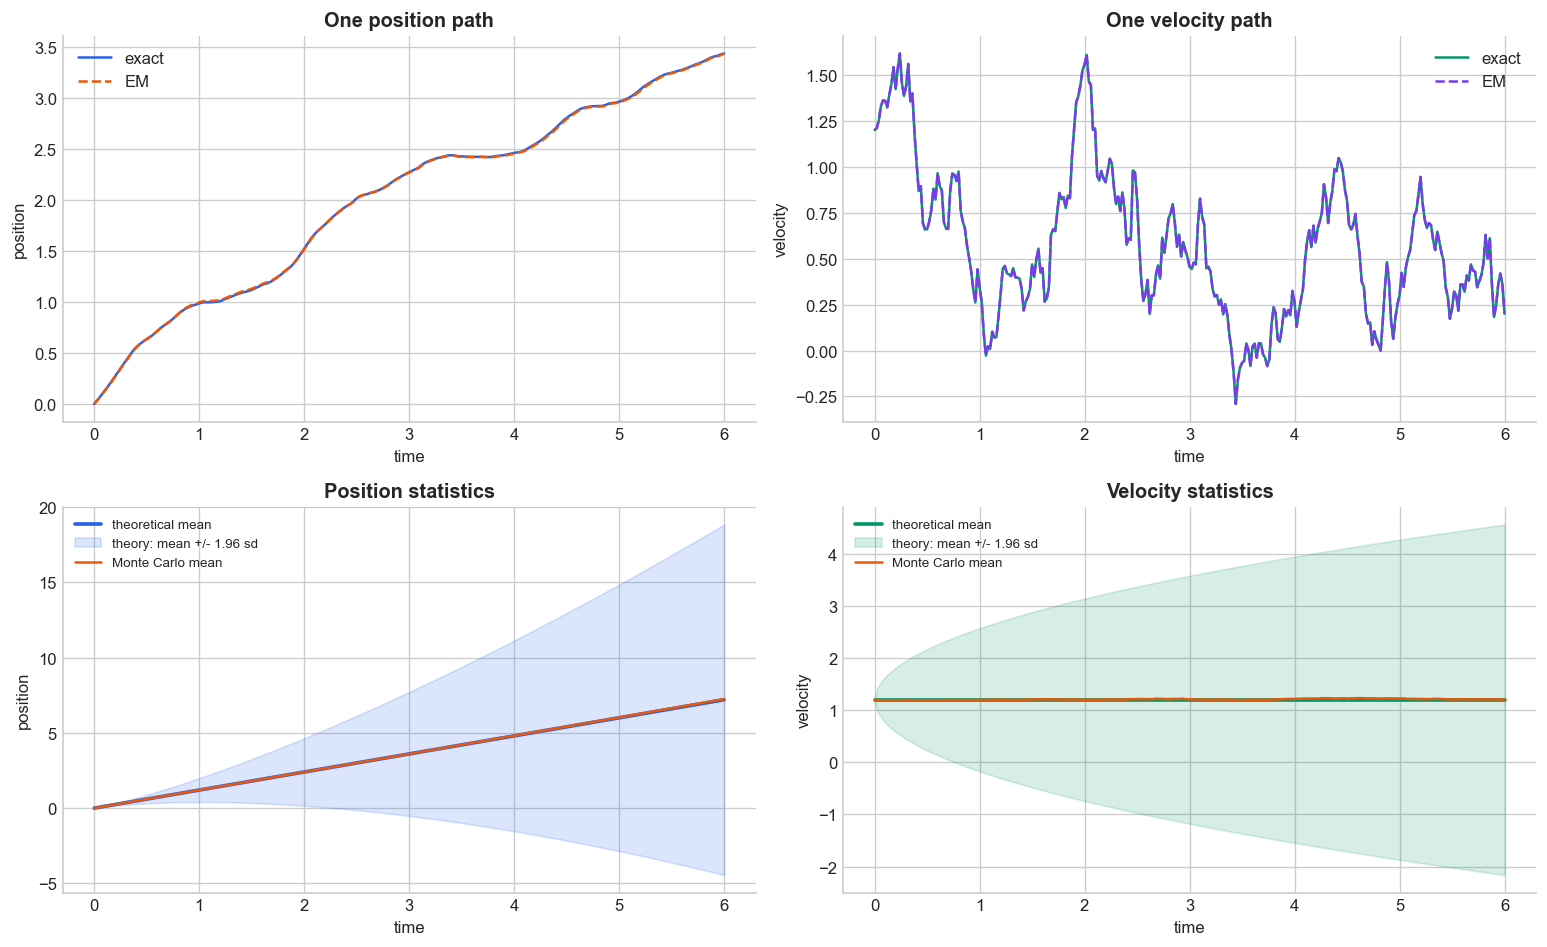

Exact-vs-EM RMSE at h=0.02: position=0.0068, velocity=0.0000


In [7]:
rng = np.random.default_rng(SEED + 5)
car_times = make_time_grid(final_time=6.0, step=0.02)
car_step = car_times[1] - car_times[0]
sigma_car = 0.7
car_F = np.array([[0.0, 1.0], [0.0, 0.0]])
car_L = np.array([0.0, sigma_car])
car_initial = np.array([0.0, 1.2])

car_exact_path, car_em_path, _ = coupled_linear_exact_and_em(
    car_F, car_L, car_initial, car_times, rng
)
car_paths, car_recursive_mean, car_recursive_covariance = exact_linear_ensemble(
    car_F,
    car_L,
    car_initial,
    car_times,
    n_paths=2200,
    rng=rng,
)

car_mean = np.column_stack(
    [
        car_initial[0] + car_initial[1] * car_times,
        np.full_like(car_times, car_initial[1]),
    ]
)
car_position_sd = sigma_car * np.sqrt(car_times**3 / 3)
car_velocity_sd = sigma_car * np.sqrt(car_times)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].plot(car_times, car_exact_path[:, 0], color=BLUE, label="exact")
axes[0, 0].plot(car_times, car_em_path[:, 0], "--", color=ORANGE, label="EM")
axes[0, 0].set(title="One position path", xlabel="time", ylabel="position")
axes[0, 0].legend()

axes[0, 1].plot(car_times, car_exact_path[:, 1], color=GREEN, label="exact")
axes[0, 1].plot(car_times, car_em_path[:, 1], "--", color=PURPLE, label="EM")
axes[0, 1].set(title="One velocity path", xlabel="time", ylabel="velocity")
axes[0, 1].legend()

add_gaussian_band(axes[1, 0], car_times, car_mean[:, 0], car_position_sd)
axes[1, 0].plot(
    car_times,
    car_paths[:, :, 0].mean(axis=0),
    color=ORANGE,
    label="Monte Carlo mean",
)
axes[1, 0].set(title="Position statistics", xlabel="time", ylabel="position")
axes[1, 0].legend(fontsize=8)

add_gaussian_band(
    axes[1, 1], car_times, car_mean[:, 1], car_velocity_sd, color=GREEN
)
axes[1, 1].plot(
    car_times,
    car_paths[:, :, 1].mean(axis=0),
    color=ORANGE,
    label="Monte Carlo mean",
)
axes[1, 1].set(title="Velocity statistics", xlabel="time", ylabel="velocity")
axes[1, 1].legend(fontsize=8)
plt.tight_layout()
plt.show()

analytic_car_covariance = np.zeros_like(car_recursive_covariance)
analytic_car_covariance[:, 0, 0] = sigma_car**2 * car_times**3 / 3
analytic_car_covariance[:, 0, 1] = sigma_car**2 * car_times**2 / 2
analytic_car_covariance[:, 1, 0] = analytic_car_covariance[:, 0, 1]
analytic_car_covariance[:, 1, 1] = sigma_car**2 * car_times
assert np.allclose(car_recursive_mean, car_mean)
assert np.allclose(car_recursive_covariance, analytic_car_covariance)

car_rmse = np.sqrt(np.mean((car_exact_path - car_em_path) ** 2, axis=0))
print(
    f"Exact-vs-EM RMSE at h={car_step:g}: "
    f"position={car_rmse[0]:.4f}, velocity={car_rmse[1]:.4f}"
)

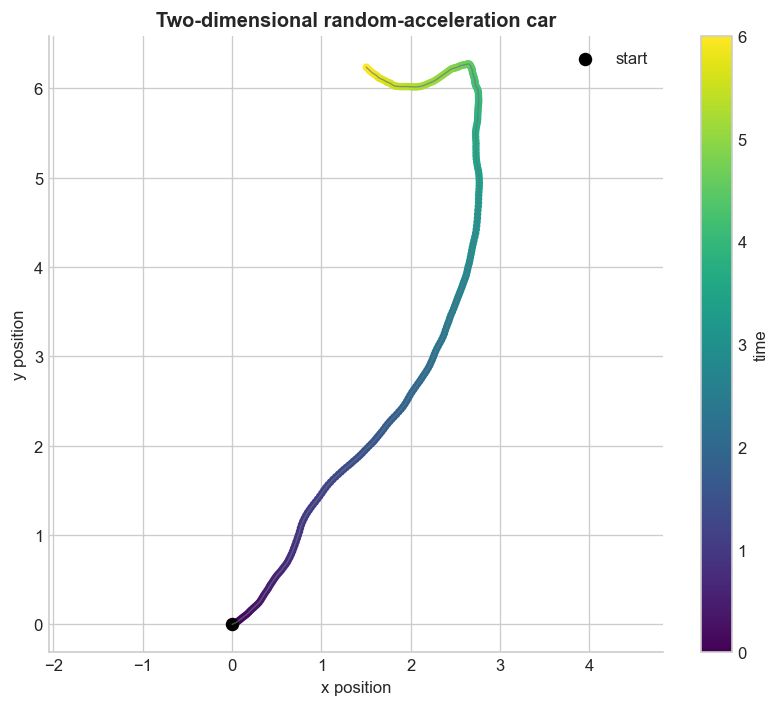

In [8]:
# Two-dimensional extension: independent random accelerations along x and y.
rng = np.random.default_rng(SEED + 55)
car_transition, car_step_covariance, _ = linear_sde_step_matrices(
    car_F, car_L, car_step
)
car_noise_root = psd_square_root(car_step_covariance)
car_2d_x = np.empty((car_times.size, 2))  # [x position, x velocity]
car_2d_y = np.empty((car_times.size, 2))  # [y position, y velocity]
car_2d_x[0] = [0.0, 1.0]
car_2d_y[0] = [0.0, 0.45]
for k in range(car_times.size - 1):
    car_2d_x[k + 1] = (
        car_transition @ car_2d_x[k] + car_noise_root @ rng.standard_normal(2)
    )
    car_2d_y[k + 1] = (
        car_transition @ car_2d_y[k] + car_noise_root @ rng.standard_normal(2)
    )

plt.figure(figsize=(7, 6))
points = plt.scatter(
    car_2d_x[:, 0],
    car_2d_y[:, 0],
    c=car_times,
    cmap="viridis",
    s=12,
)
plt.plot(car_2d_x[:, 0], car_2d_y[:, 0], color=GRAY, linewidth=0.8, alpha=0.7)
plt.scatter(car_2d_x[0, 0], car_2d_y[0, 0], color="black", s=50, label="start")
plt.colorbar(points, label="time")
plt.axis("equal")
plt.xlabel("x position")
plt.ylabel("y position")
plt.title("Two-dimensional random-acceleration car")
plt.legend()
plt.tight_layout()
plt.show()

**What to notice.** Velocity is Brownian motion plus its initial value, so it is continuous
but rough. Position integrates that rough velocity and is smoother. EM gets the velocity
update exactly at grid points, but its position update uses only the velocity at the start
of each interval; the exact transition also accounts for random acceleration *within* the
interval.

## 6. Geometric Brownian motion / the Black-Scholes asset process

The Black-Scholes asset model in Example 3.8 is

$$dS_t=\mu S_t\,dt+\sigma S_t\,dW_t,\qquad S_0>0.$$

**Drift:** $\mu S_t$. The expected absolute growth scales with the current level.

**Diffusion:** $\sigma S_t$. Random fluctuations are proportional to the current level,
so $\sigma$ is naturally interpreted as volatility.

This is linear in $S_t$ but has **multiplicative** noise. Apply Itô's formula to
$Y_t=\log S_t$:

$$d\log S_t=\left(\mu-\frac12\sigma^2\right)dt+\sigma\,dW_t.$$

The extra $-\sigma^2/2$ is the Itô correction. Integrating and exponentiating gives the
exact solution from Example 4.7,

$$
S_t=S_0\exp\!\left[
\left(\mu-\frac12\sigma^2\right)t+\sigma W_t
\right].
$$

Therefore $S_t$ is lognormal and always positive, with

$$
\mathbb E[S_t]=S_0e^{\mu t},\qquad
\operatorname{Var}(S_t)=S_0^2e^{2\mu t}(e^{\sigma^2t}-1).
$$

This section simulates the asset process; it is not deriving the separate option-pricing
PDE or the Black-Scholes option formula.

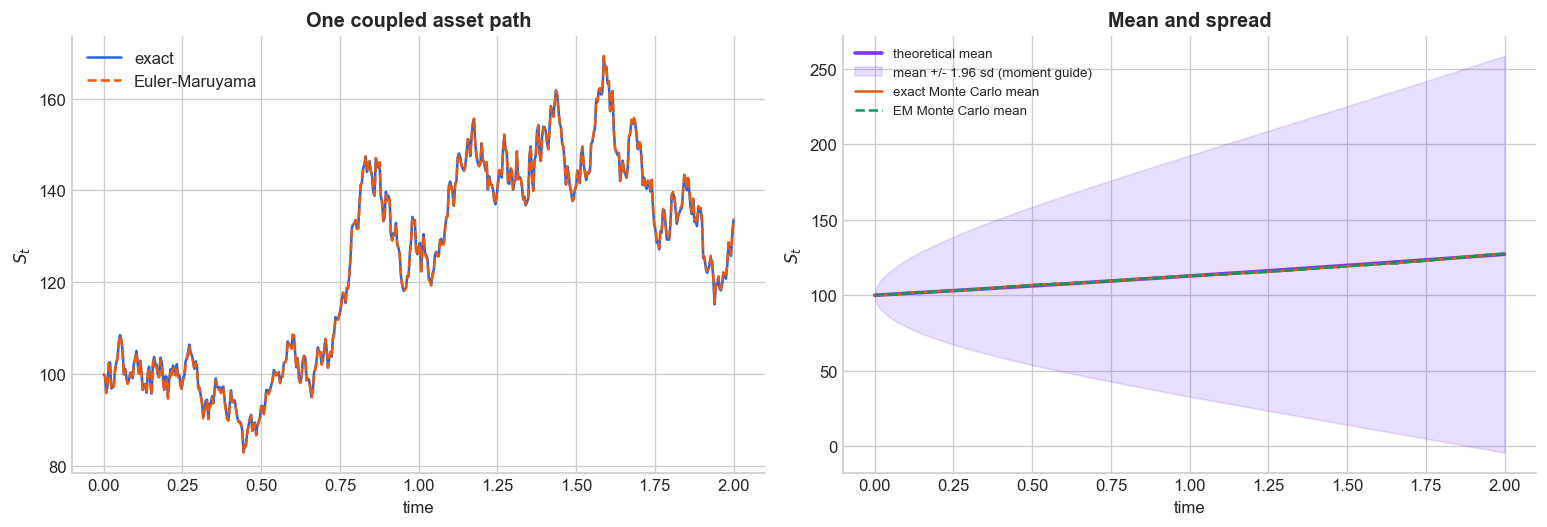

Terminal exact mean 127.53 (theory 127.12)
Terminal EM mean 127.54; path RMSE for the displayed path 0.264
Minimum exact value over all paths: 18.4245


In [9]:
rng = np.random.default_rng(SEED + 6)
gbm_times = make_time_grid(final_time=2.0, step=0.004)
gbm_step = gbm_times[1] - gbm_times[0]
n_gbm_paths = 3200
s0, mu_gbm, sigma_gbm = 100.0, 0.12, 0.35
gbm_dW = brownian_increments(
    rng, n_paths=n_gbm_paths, n_steps=gbm_times.size - 1, step=gbm_step
)
gbm_W = np.column_stack([np.zeros(n_gbm_paths), np.cumsum(gbm_dW, axis=1)])
gbm_exact = s0 * np.exp(
    (mu_gbm - 0.5 * sigma_gbm**2) * gbm_times[None, :]
    + sigma_gbm * gbm_W
)
gbm_em = euler_maruyama_scalar(
    drift=lambda s, t: mu_gbm * s,
    diffusion=lambda s, t: sigma_gbm * s,
    initial_value=s0,
    times=gbm_times,
    increments=gbm_dW,
)

gbm_mean = s0 * np.exp(mu_gbm * gbm_times)
gbm_variance = s0**2 * np.exp(2 * mu_gbm * gbm_times) * (
    np.exp(sigma_gbm**2 * gbm_times) - 1
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(gbm_times, gbm_exact[0], color=BLUE, label="exact")
axes[0].plot(gbm_times, gbm_em[0], "--", color=ORANGE, label="Euler-Maruyama")
axes[0].set(title="One coupled asset path", xlabel="time", ylabel="$S_t$")
axes[0].legend()

add_gaussian_band(
    axes[1],
    gbm_times,
    gbm_mean,
    np.sqrt(gbm_variance),
    color=PURPLE,
    label="mean +/- 1.96 sd (moment guide)",
)
axes[1].plot(
    gbm_times,
    gbm_exact.mean(axis=0),
    color=ORANGE,
    label="exact Monte Carlo mean",
)
axes[1].plot(
    gbm_times,
    gbm_em.mean(axis=0),
    "--",
    color=GREEN,
    label="EM Monte Carlo mean",
)
axes[1].set(title="Mean and spread", xlabel="time", ylabel="$S_t$")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

terminal_exact = gbm_exact[:, -1]
terminal_em = gbm_em[:, -1]
print(
    f"Terminal exact mean {terminal_exact.mean():.2f} "
    f"(theory {gbm_mean[-1]:.2f})"
)
print(
    f"Terminal EM mean {terminal_em.mean():.2f}; "
    f"path RMSE for the displayed path "
    f"{np.sqrt(np.mean((gbm_exact[0] - gbm_em[0]) ** 2)):.3f}"
)
print(f"Minimum exact value over all paths: {gbm_exact.min():.4f}")

**What to notice.** The exact solution never crosses zero because it is an exponential.
EM approximates the multiplicative dynamics well at a small step, but its one-step factor
$1+\mu h+\sigma\Delta W$ can be negative for a sufficiently large adverse increment.
A log-Euler update - applying EM to $\log S$ and exponentiating - is exact here because
the transformed SDE has constant coefficients.

The shaded region is a mean-plus/minus-standard-deviation guide, not an exact 95% interval:
the lognormal distribution is skewed, so its true equal-tail interval is asymmetric.

## 7. Noisy pendulum: nonlinear drift, numerical solution

Example 3.6 starts from a unit-length, unit-mass pendulum with a random torque,

$$\ddot\theta_t=-g\sin(\theta_t)+\sigma\,\frac{dW_t}{dt}.$$

With angular velocity $\omega_t=\dot\theta_t$,

$$
d\theta_t=\omega_t\,dt,
\qquad
d\omega_t=-g\sin(\theta_t)\,dt+\sigma\,dW_t.
$$

**Drift:** $(\omega,-g\sin\theta)^\top$. Gravity is nonlinear because of the sine.

**Diffusion:** $(0,\sigma)^\top$. Random torque enters angular acceleration.

There is no general elementary closed-form stochastic solution. Chapter 4, Section 4.4
emphasizes that nonlinear SDEs do not have a universal exact solution method. We therefore
use Euler-Maruyama:

$$
\theta_{k+1}=\theta_k+\omega_kh,
\qquad
\omega_{k+1}=\omega_k-g\sin(\theta_k)h+\sigma\Delta W_k.
$$

To make the numerical error visible, we compare a fine EM path with a coarser EM path.
The coarse increments are sums of the fine increments, so both approximations use the
same Brownian motion.

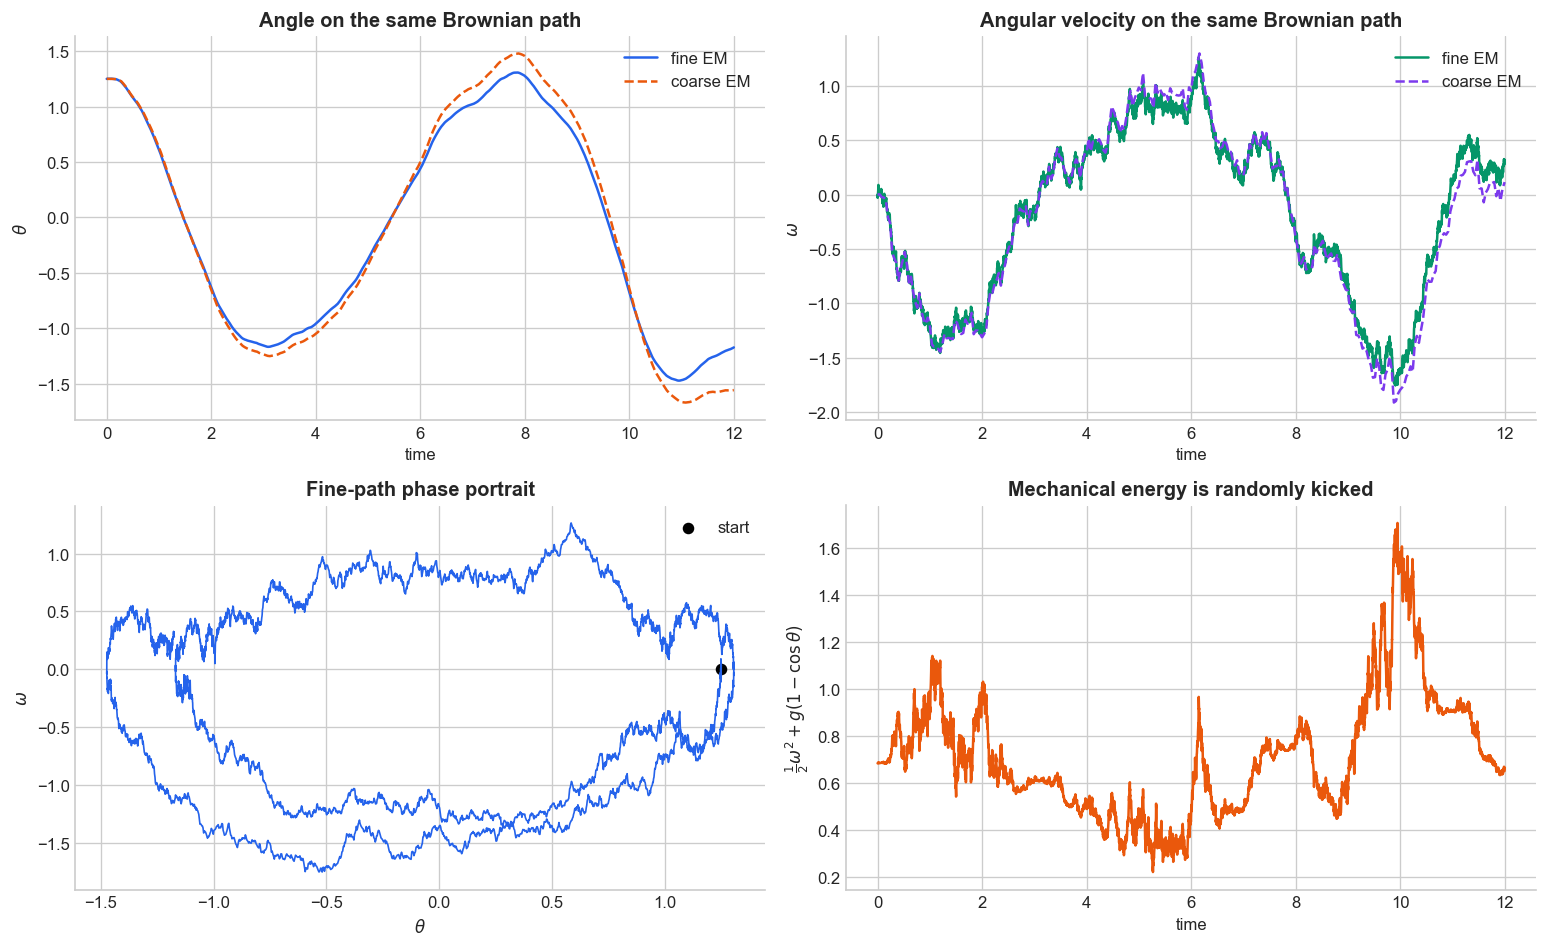

Coarse-vs-fine EM RMSE at shared times: angle=0.1306, velocity=0.1021


In [10]:
def simulate_pendulum_em(
    increments: np.ndarray,
    step: float,
    theta0: float,
    omega0: float,
    gravity: float,
    noise_scale: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Simulate the noisy pendulum with Euler-Maruyama."""
    theta = np.empty(increments.size + 1)
    omega = np.empty(increments.size + 1)
    theta[0], omega[0] = theta0, omega0
    for k, increment in enumerate(increments):
        theta[k + 1] = theta[k] + omega[k] * step
        omega[k + 1] = (
            omega[k]
            - gravity * np.sin(theta[k]) * step
            + noise_scale * increment
        )
    return theta, omega


rng = np.random.default_rng(SEED + 7)
pendulum_final_time = 12.0
pendulum_fine_step = 0.002
pendulum_coarse_step = 0.04
aggregation = int(round(pendulum_coarse_step / pendulum_fine_step))
pendulum_fine_times = make_time_grid(pendulum_final_time, pendulum_fine_step)
pendulum_coarse_times = make_time_grid(pendulum_final_time, pendulum_coarse_step)
gravity_p, sigma_p = 1.0, 0.45
theta0_p, omega0_p = 1.25, 0.0

pendulum_fine_dW = np.sqrt(pendulum_fine_step) * rng.standard_normal(
    pendulum_fine_times.size - 1
)
pendulum_coarse_dW = pendulum_fine_dW.reshape(-1, aggregation).sum(axis=1)

theta_fine, omega_fine = simulate_pendulum_em(
    pendulum_fine_dW,
    pendulum_fine_step,
    theta0_p,
    omega0_p,
    gravity_p,
    sigma_p,
)
theta_coarse, omega_coarse = simulate_pendulum_em(
    pendulum_coarse_dW,
    pendulum_coarse_step,
    theta0_p,
    omega0_p,
    gravity_p,
    sigma_p,
)
energy_fine = 0.5 * omega_fine**2 + gravity_p * (1 - np.cos(theta_fine))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].plot(pendulum_fine_times, theta_fine, color=BLUE, label="fine EM")
axes[0, 0].plot(
    pendulum_coarse_times,
    theta_coarse,
    "--",
    color=ORANGE,
    label="coarse EM",
)
axes[0, 0].set(
    title="Angle on the same Brownian path", xlabel="time", ylabel=r"$\theta$"
)
axes[0, 0].legend()

axes[0, 1].plot(pendulum_fine_times, omega_fine, color=GREEN, label="fine EM")
axes[0, 1].plot(
    pendulum_coarse_times,
    omega_coarse,
    "--",
    color=PURPLE,
    label="coarse EM",
)
axes[0, 1].set(
    title="Angular velocity on the same Brownian path",
    xlabel="time",
    ylabel=r"$\omega$",
)
axes[0, 1].legend()

axes[1, 0].plot(theta_fine, omega_fine, color=BLUE, linewidth=1.0)
axes[1, 0].scatter(theta_fine[0], omega_fine[0], color="black", s=35, label="start")
axes[1, 0].set(
    title="Fine-path phase portrait", xlabel=r"$\theta$", ylabel=r"$\omega$"
)
axes[1, 0].legend()

axes[1, 1].plot(pendulum_fine_times, energy_fine, color=ORANGE)
axes[1, 1].set(
    title="Mechanical energy is randomly kicked",
    xlabel="time",
    ylabel=r"$\frac{1}{2}\omega^2+g(1-\cos\theta)$",
)
plt.tight_layout()
plt.show()

shared_indices = np.arange(pendulum_coarse_times.size) * aggregation
angle_grid_rmse = np.sqrt(
    np.mean((theta_fine[shared_indices] - theta_coarse) ** 2)
)
velocity_grid_rmse = np.sqrt(
    np.mean((omega_fine[shared_indices] - omega_coarse) ** 2)
)
print(
    "Coarse-vs-fine EM RMSE at shared times: "
    f"angle={angle_grid_rmse:.4f}, velocity={velocity_grid_rmse:.4f}"
)

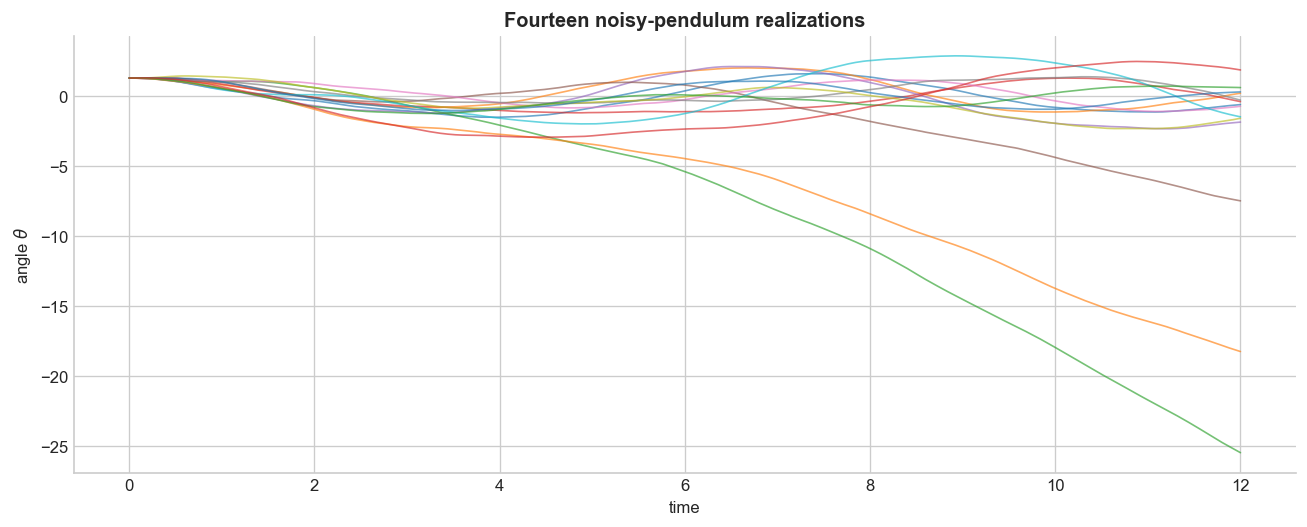

In [11]:
# A small ensemble shows that “the solution” is a distribution of paths.
rng = np.random.default_rng(SEED + 77)
n_pendulum_paths = 14
pendulum_ensemble = []
for _ in range(n_pendulum_paths):
    increments = np.sqrt(pendulum_coarse_step) * rng.standard_normal(
        pendulum_coarse_times.size - 1
    )
    theta_path, _ = simulate_pendulum_em(
        increments,
        pendulum_coarse_step,
        theta0_p,
        omega0_p,
        gravity_p,
        sigma_p,
    )
    pendulum_ensemble.append(theta_path)
pendulum_ensemble = np.asarray(pendulum_ensemble)

plt.figure(figsize=(11, 4.5))
plt.plot(
    pendulum_coarse_times,
    pendulum_ensemble.T,
    linewidth=1.0,
    alpha=0.65,
)
plt.xlabel("time")
plt.ylabel(r"angle $\theta$")
plt.title("Fourteen noisy-pendulum realizations")
plt.tight_layout()
plt.show()

**What to notice.** The two numerical paths initially agree because they share the same
Brownian motion, but nonlinear dynamics amplify their discretization differences. The
fine path is not claimed to be exact; it is a more resolved reference. A convergence study
would repeat the calculation with successively halved step sizes and examine how the
strong or weak error changes.

Without noise, the undamped pendulum conserves
$E=\tfrac12\omega^2+g(1-\cos\theta)$. Random torque injects and removes energy, so the
displayed energy fluctuates. (Numerical discretization also introduces a smaller energy
error.)

## Summary: what can be solved exactly?

| Model | Drift | Diffusion | Exact result used here | Numerical role |
|---|---|---|---|---|
| Brownian motion | $0$ | $\sigma$ | $X_t=x_0+\sigma W_t$ | EM is exact on the grid |
| OU | $-\lambda x$ | $\sigma$ | integrating factor; Gaussian transition | compare EM path and moments |
| Vasicek | $\theta(\mu-x)$ | $\sigma$ | shift by $\mu$, then solve OU | compare EM and terminal density |
| Noisy spring | $Fx$ | $L$ | matrix exponential and Gaussian convolution | compare exact transition with EM |
| Random-acceleration car | $(v,0)$ | $(0,\sigma)$ | integrated Brownian motion | compare exact transition with EM |
| Geometric Brownian motion | $\mu s$ | $\sigma s$ | Itô transform $\log s$ | compare exact path/moments with EM |
| Noisy pendulum | $(\omega,-g\sin\theta)$ | $(0,\sigma)$ | no general closed form | EM; fine-versus-coarse study |

The useful rule of thumb is:

$$
\boxed{\text{linear additive-noise SDEs: often exactly Gaussian}}
$$

$$
\boxed{\text{special transformable nonlinear/multiplicative SDEs: sometimes exact}}
$$

$$
\boxed{\text{general nonlinear SDEs: usually numerical}}
$$

“Exact” can mean an explicit stochastic integral, an exact transition distribution, or
closed-form moments. It does **not** mean that a random path becomes deterministic.

## Suggested experiments

Try changing one parameter at a time and predict the plot before rerunning the cell:

1. **OU:** double $\lambda$. Does the mean decay faster? What happens to the stationary
   variance $\sigma^2/(2\lambda)$?
2. **Vasicek:** move $\mu$ and verify that it shifts the long-run center without changing
   the stationary variance.
3. **Spring:** set $\gamma=0$. With continuing random forcing, what happens to the energy
   and variance?
4. **Car:** halve the horizon. Check the $t^3$ scaling of position variance.
5. **GBM:** increase the EM step substantially. Can EM produce a negative value even
   though the exact solution cannot?
6. **Pendulum:** halve the fine and coarse step sizes together. Does the coarse-versus-fine
   discrepancy shrink?

For a more formal convergence experiment, simulate many Brownian paths at several step
sizes, compute the terminal pathwise error against an exact solution, and plot log(error)
against log(step size). The slope estimates the strong convergence order.

## Reference

Särkkä, S., & Solin, A. (2019). *Applied Stochastic Differential Equations*.
Cambridge University Press. Primary material used here: Chapters 3-4, with the exact
Wiener-velocity transition in Example 6.3.

All simulations use a fixed seed for reproducibility. Exact grid transitions are sampled
from their mathematically exact Gaussian laws; plotted Monte Carlo curves still have
finite-sample noise.